# Training dynamics of the real-only baselines

Epoch trajectories of every loss component, per repetition and as group bands, to see whether training converged, whether repetitions agree and whether any component dominates late epochs.

## Introduction

The trajectories complement the final values of `part_0_03`: two runs can end at the same value after very
different paths, and a component that still decreases at the last epoch indicates an unfinished
optimisation (10 epochs, patience 10).

### Assumptions

The trainer builds its validation and test data loaders from the phase configuration,
including `supervision_sampling` (positive : unlabelled = 1 : 1, drawn with replacement).
Every *recorded* validation and test value is therefore an estimate on a re-sampled,
class-balanced population, not the mean over the plain partition. Checkpoint selection
(`restore_best`) uses the same sampled validation loss.

### Notation

* Epoch $e = 1, \dots, 10$; component names as in `part_0_03`.
* Group band: minimum to maximum over the five repetitions at each epoch.

## Configuration

### Scope

This notebook describes the real-only baselines. Since the full campaign run its tables contain all 310 models; `table` keeps the baseline rows only. The training histories of the pretraining lineages are in `part_0_05_synthetic_pretraining_curves` and `part_0_06_finetuning_curves`.

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "training_dynamics"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


BASELINE_MODELS = catalog[catalog.role == settings["baseline_role"]]


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute, restricted to the real-only baselines.

    The table covers every campaign model; the pretraining lineages are analysed in parts 0_05 and 0_06.
    """
    frame = load_table(settings, ANALYSIS, name, AXIS)
    if "variant" in frame.columns:
        return frame[frame.variant == "baseline"]
    if "model_id" in frame.columns:
        return frame[frame.model_id.isin(BASELINE_MODELS.model_id)]
    if "display_label" in frame.columns:
        return frame[frame.display_label.isin(BASELINE_MODELS.display_label)]
    return frame


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(BASELINE_MODELS.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

COMPONENTS = ['masserstein', 'molecule_vpu__vpu', 'contractive', 'peak_permutation', 'total_loss']

Analysis: training_dynamics | axis: None | models: 310
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`training_dynamics` reads `history.json` of every selected model; no inference is involved.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis training_dynamics > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Per-repetition trajectories of every component

### Methodology

#### Theoretical

Every repetition is shown individually so that a single divergent run is not averaged away.

#### Implementation

`history` rows are drawn directly; the test value is placed at the last epoch.

#### Figure descriptions

One panel per component; x = epoch, y = loss; colour = model group; solid = train, dashed = validation,
star = test value of the restored checkpoint.

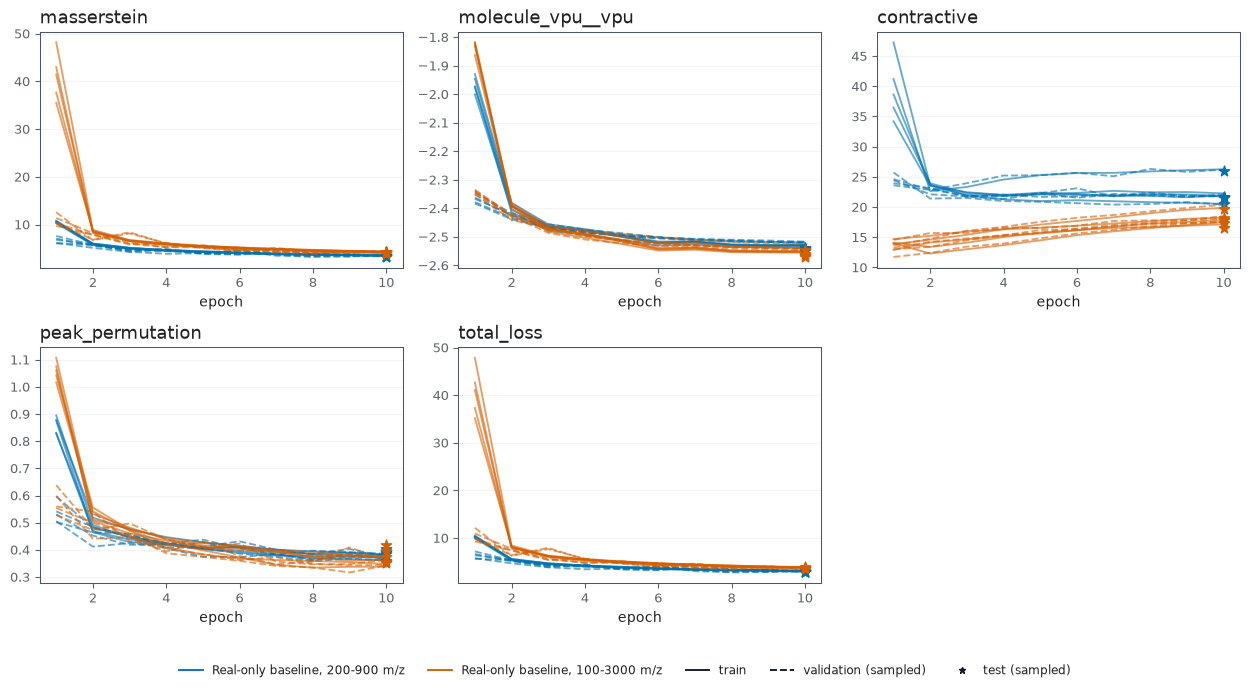

In [3]:
history = table('history')
figures.loss_trajectories(history, components=COMPONENTS, labels=LABELS, theme=theme);

### Remarks

- Repetitions follow nearly identical paths; no divergent run.

### Notes

## Group bands across repetitions

### Methodology

#### Theoretical

The band width at an epoch measures the between-repetition variability of the optimisation; a band that
narrows over epochs indicates convergence to comparable solutions.

#### Implementation

`group_trajectories` holds mean, minimum and maximum over repetitions per group, epoch, split and component.

#### Figure descriptions

One panel per component; line = mean over repetitions, shaded band = minimum to maximum.

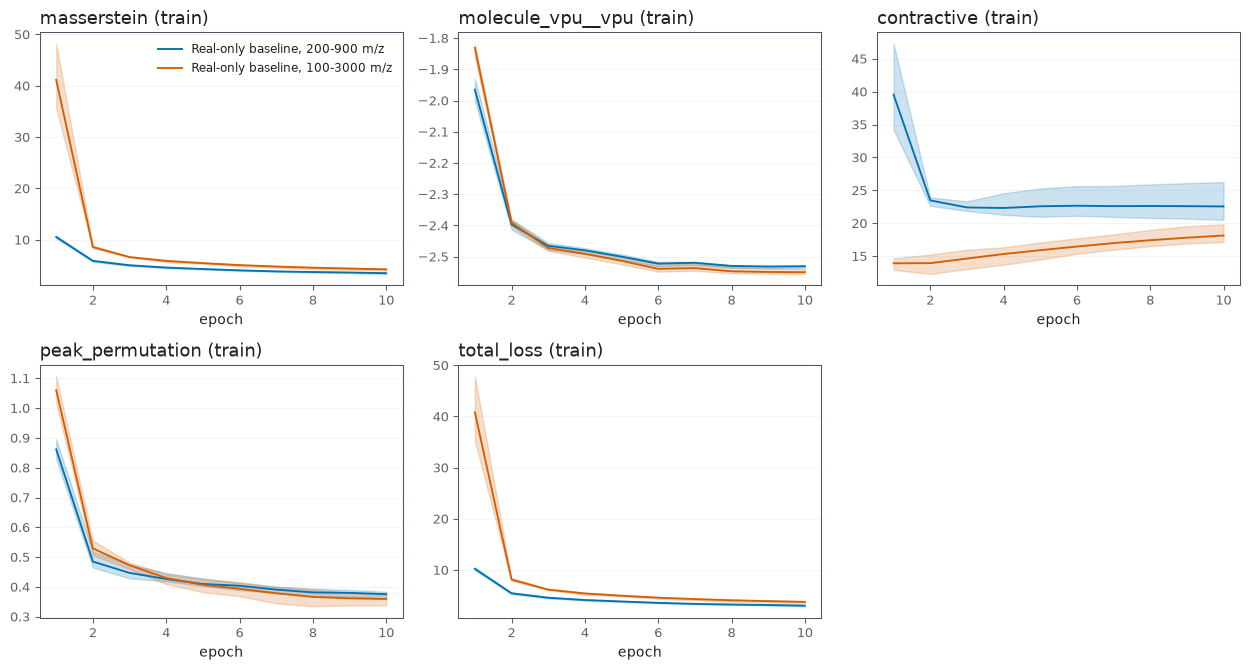

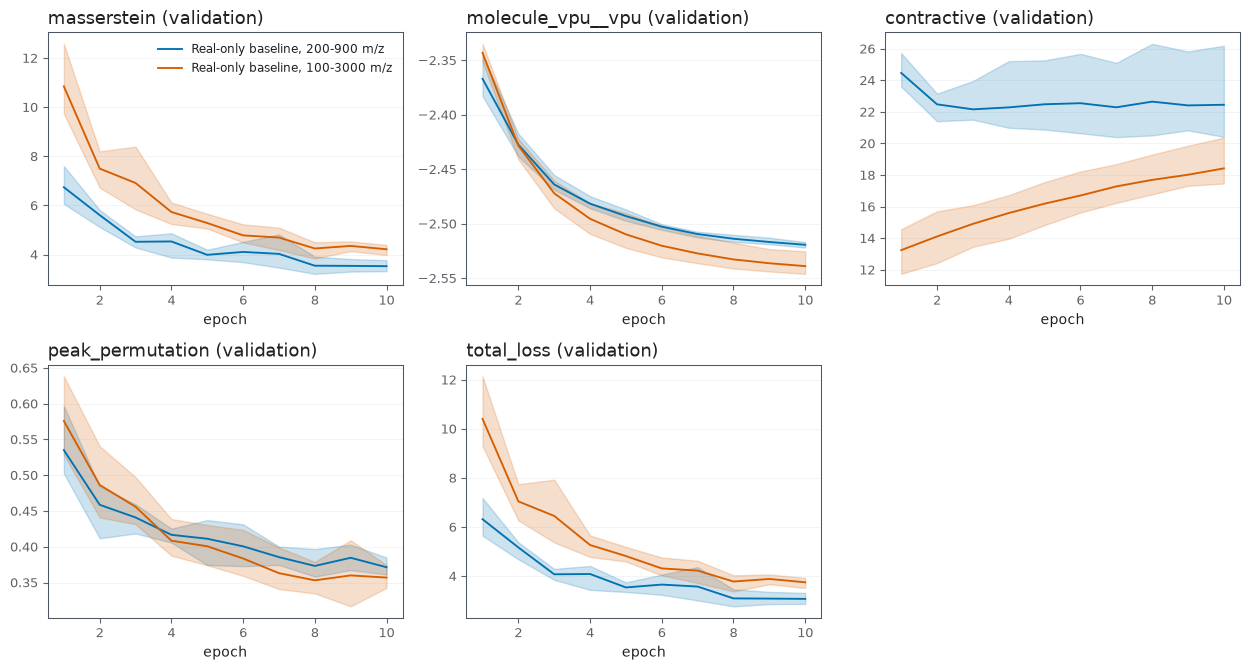

In [4]:
trajectories = table('group_trajectories')
figures.group_bands(trajectories, components=COMPONENTS, labels=LABELS, split='train', theme=theme);
figures.group_bands(trajectories, components=COMPONENTS, labels=LABELS, split='validation', theme=theme);

### Remarks

- Mean validation total loss still decreases at epoch 10 on both axes (200-900: 3.09 -> 3.07 between epochs 8 and 10; 100-3000: 3.78 -> 3.75): training with 10 epochs is close to, but not at, convergence.

### Notes

## Epoch durations and checkpoint selection

### Methodology

#### Theoretical

Durations document the computational cost per axis; the epoch of the restored checkpoint shows whether the
best (sampled) validation loss was reached at the end of training.

#### Implementation

`epochs` holds wall time and the `is_best` flag of every epoch.

#### Figure descriptions

No figure; the table gives per model the median epoch duration and the restored epoch.

In [5]:
epochs = table('epochs')
display(epochs.groupby(['display_label', 'repetition']).agg(median_epoch_seconds=('duration_seconds', 'median'), restored_epoch=('epoch', lambda values: int(values[epochs.loc[values.index, 'is_best']].max()))))

median_epoch_seconds  restored_epoch
display_label                    repetition                                      
Real-only baseline, 100-3000 m/z 0                       145.8265              10
                                 1                       132.7818               9
                                 2                       148.0541               8
                                 3                       160.6845               9
                                 4                       139.8513              10
Real-only baseline, 200-900 m/z  0                       139.1346              10
                                 1                       475.7138               8
                                 2                       136.2055              10
                                 3                       139.5718               8
                                 4                       139.3280               9

### Remarks

- Median epoch time about 135-160 s on both axes despite the 4x wider input; one outlier run (200-900, repetition 1: 476 s).

### Notes

## Results / Summary

### LLM

- **Observed:** training is stable and reproducible across repetitions on both axes; the band between repetitions narrows over epochs.
- **Observed:** losses still decrease slightly at the last epoch; a longer schedule could lower all components somewhat. This affects both axes alike and does not change their comparison.
- **Hypothesis:** the small late decrease suggests the baselines are not capacity-limited in optimisation terms; whether more epochs change held-out behaviour is untested.

### Person